# Classification Model for Diabetes Detection

In this project, we implement a machine learning classification model trained to predict diabetes in patients based on various medical features such as blood glucose levels, BMI, blood pressure, etc. Several classification algorithms are evaluated to determine which one yields the best performance.

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [103]:
df = pd.DataFrame(pd.read_csv("diabetes.csv"))

## Exploratory Data Analysis (EDA)

In [104]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB



##### The dataset consists of 768 rows and 9 variables: 8 medical features and a target outcome indicating diabetes diagnosis (1 for diabetic, 0 for non-diabetic). We will begin by analyzing the distribution of data for each variable.

In [106]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [107]:
df.isnull().any()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

The dataset does not contain any apparent missing values.

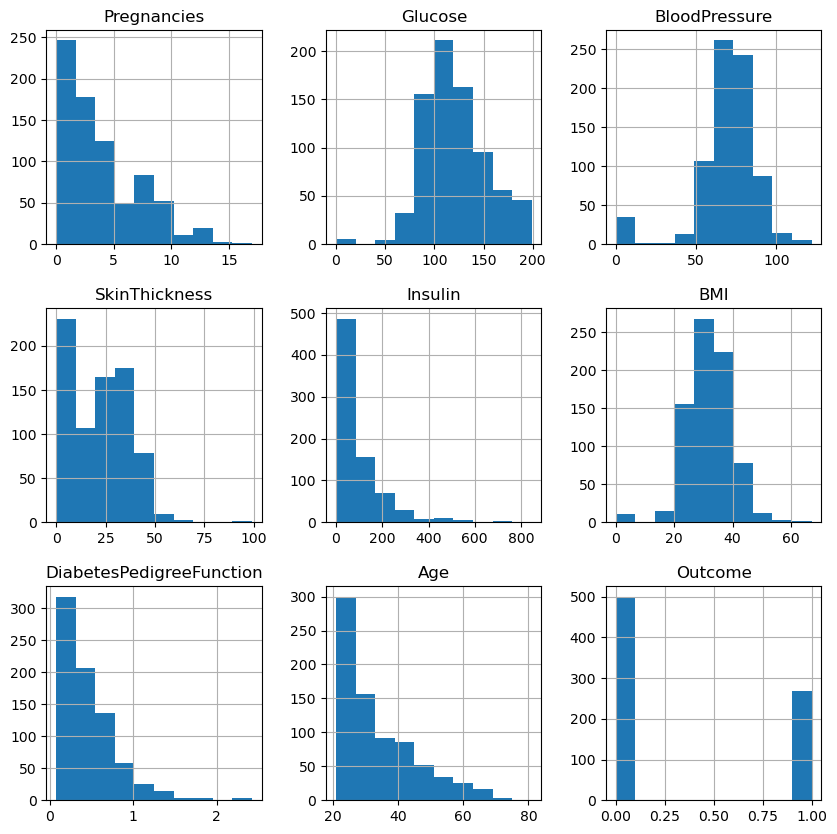

In [108]:
df.hist(figsize = (10,10))
plt.show()

Despite having no explicit missing values, several variables (such as Insulin, BMI, Blood Pressure, etc.) contain a significant number of 0 values. This suggests that missing values were recorded as 0. To prevent them from distorting the modeling phase, we will convert these zeros to NaNs so they can be properly handled during model training.

In [109]:
columnas_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columnas_cero] = df[columnas_cero].replace(0, np.nan)
for col in columnas_cero:
  df[col] = df[col].fillna(df[col].median())

In [110]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


<Axes: >

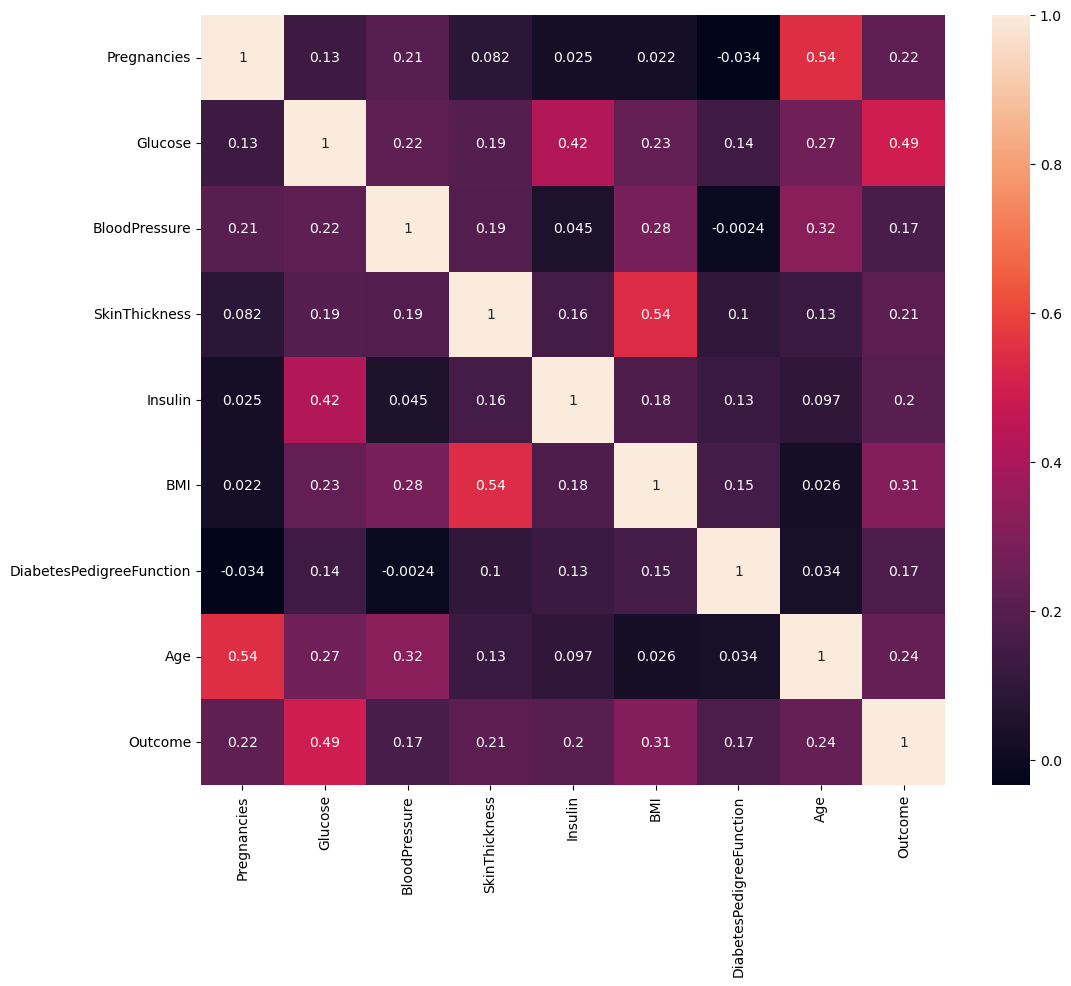

In [111]:
plt.figure(figsize = (12,10))
sns.heatmap(df.corr(),annot = True)

The correlation matrix shows a significant linear relationship between glucose levels and the diabetes diagnosis; on the other hand, variables such as blood pressure or skin thickness are practically irrelevant to the outcome. Furthermore, it is worth noting the low correlation between the diabetes diagnosis and insulin levels, despite insulin being a hormone widely associated with the disease.

C:\Users\User\AppData\Local\Temp\ipykernel_15796\712467204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Outcome'],palette='Set1')


<Axes: xlabel='count', ylabel='Outcome'>

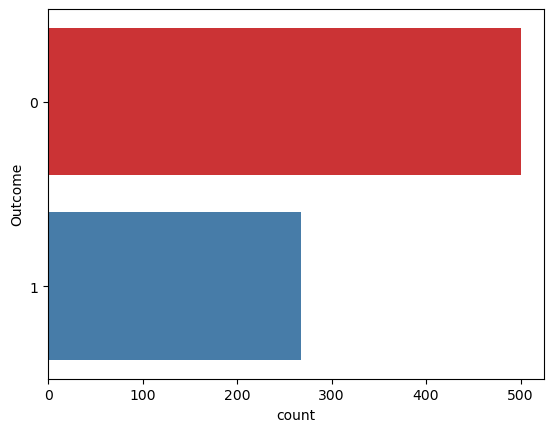

In [112]:
sns.countplot(y=df['Outcome'],palette='Set1')

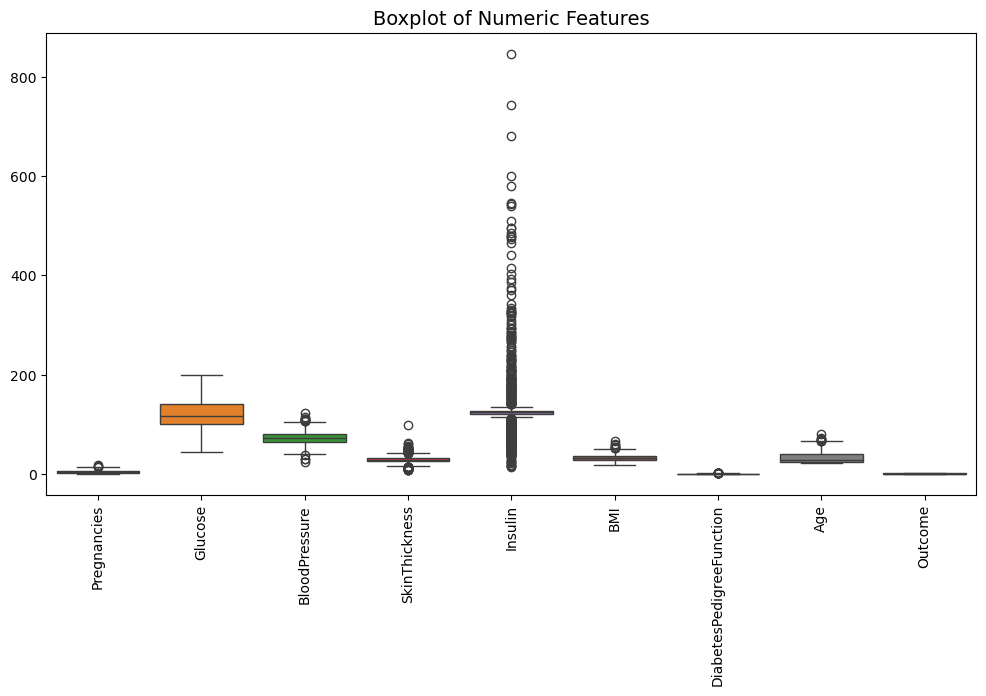

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Selecciona solo las columnas numéricas del DataFrame
sns.boxplot(data=df.select_dtypes(include=['number']))

plt.title(
    'Boxplot of Numeric Features',
    fontsize=14,
)
plt.xticks(rotation=90)  
plt.show()

## Modeling

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1),
                                                    df['Outcome'], test_size=0.20,
                                                    random_state=101)

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(X_train)
Xtest_scaled = scaler.transform(X_test)

# Each model with its hyperparameter grid
models = {
    'Logistic Regression': (LogisticRegression(max_iter=400),
                            {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'newton-cg']}),
    'KNN': (KNN(),
            {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}),
    'SVM': (SVC(kernel='rbf'),
            {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}),
    'Neural Network': (MLPClassifier(max_iter=1000, random_state=101),
                       {'hidden_layer_sizes': [(32,), (64, 32)], 'alpha': [0.0001, 0.001]}),
    'Random Forest': (RandomForestClassifier(random_state=101),
                      {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}),
    'XGBoost': (xgb.XGBClassifier(eval_metric='logloss', random_state=101),
                {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}),
}

results = []
best_models = {}
for name, (estimator, param_grid) in models.items():
    grid = GridSearchCV(estimator, param_grid, cv=3, n_jobs=-1)
    grid.fit(Xtrain_scaled, y_train)
    best = grid.best_estimator_  # already refitted on the full training set
    best_models[name] = best
    results.append({
        'Model': name,
        'Train accuracy': accuracy_score(y_train, best.predict(Xtrain_scaled)),
        'Test accuracy': accuracy_score(y_test, best.predict(Xtest_scaled)),
    })

# Accuracy of every model
for r in results:
    print(f"{r['Model']}: Train = {r['Train accuracy']:.4f} | Test = {r['Test accuracy']:.4f}")

# Confusion matrix of best models on test ratings (test set; rows = actual, columns = predicted)
print()
for name, best in best_models.items():
    if name == 'KNN' or name == 'SVM':
        print(name)
        print(classification_report(y_test,best.predict(Xtest_scaled)))
        print(confusion_matrix(y_test, best.predict(Xtest_scaled)))
        print()

Logistic Regression: Train = 0.7704 | Test = 0.7662
KNN: Train = 0.7932 | Test = 0.8052
SVM: Train = 0.8208 | Test = 0.7987
Neural Network: Train = 0.7964 | Test = 0.7922
Random Forest: Train = 0.8485 | Test = 0.7532
XGBoost: Train = 0.9772 | Test = 0.7532

KNN
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       103
           1       0.72      0.67      0.69        51

    accuracy                           0.81       154
   macro avg       0.78      0.77      0.78       154
weighted avg       0.80      0.81      0.80       154

[[90 13]
 [17 34]]

SVM
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       103
           1       0.73      0.63      0.67        51

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.76       154
weighted avg       0.79      0.80      0.79       154

[[91 12]
 [19 32]]

